## Tiny SQL Development  

### Set up

In [ ]:
%%bash
sudo apt-get update
sudo apt-get install -y gettext-base

#### Install depdenence Library

In [ ]:
!pip install -q sqlglot pyyaml datasets seaborn python-dotenv sqlalchemy>=2.0 pyyaml --extra-index-url https://pypi.org/simple   --no-warn-script-location

#### Import Libraries

In [ ]:
import os
import sys
import dotenv
import json
import logging
import sqlglot
import random
import yaml
import copy

project_dir=f'/content/aai-590-tinysql'
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
    sys.path.insert(1, f"{project_dir}/src")

os.environ['PROJECT_DIR'] = project_dir

if os.path.exists(f'{project_dir}/env.txt'):
    dotenv.load_dotenv(f"{project_dir}/env.txt")
else:
    print("Env file does not exist.")

Env file does not exist.


In [ ]:
from datasets import load_dataset
from huggingface_hub import login

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

from util.config_loader import config_loader

logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("sqlglot").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

### Data Ingestion

In [ ]:
hf_token=os.getenv("HF_TOKEN")

In [ ]:
# Explicitly log in to Hugging Face Hub
login(token=hf_token)

In [ ]:
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.select(range(100000))

In [ ]:
test_ds = load_dataset("gretelai/synthetic_text_to_sql", split="test")
tinycode_test_ds = test_ds.select(range(5000))
print (tinycode_test_ds[0])


{'id': 1, 'domain': 'artificial intelligence', 'domain_description': 'AI data on algorithmic fairness, AI safety, explainable AI, and creative AI applications.', 'sql_complexity': 'basic SQL', 'sql_complexity_description': 'basic SQL with a simple select statement', 'sql_task_type': 'analytics and reporting', 'sql_task_type_description': 'generating reports, dashboards, and analytical insights', 'sql_prompt': "What is the average explainability score of creative AI applications in 'Europe' and 'North America' in the 'creative_ai' table?", 'sql_context': "CREATE TABLE creative_ai (application_id INT, name TEXT, region TEXT, explainability_score FLOAT); INSERT INTO creative_ai (application_id, name, region, explainability_score) VALUES (1, 'ApplicationX', 'Europe', 0.87), (2, 'ApplicationY', 'North America', 0.91), (3, 'ApplicationZ', 'Europe', 0.84), (4, 'ApplicationAA', 'North America', 0.93), (5, 'ApplicationAB', 'Europe', 0.89);", 'sql': "SELECT AVG(explainability_score) FROM creativ

### Preprocessing & Visualizations

In [ ]:
def apply_tinycode_logic(example):
    original_sql = example['sql']
    schema = example['sql_context']
    question = example['sql_prompt']
    explanation = example['sql_explanation']

    # --- LAYER 1 & 3: Dialect Transpilation & BQ Normalization ---
    try:
        # Transpile to BigQuery and force backticks (identify=True)
        bq_sql = sqlglot.transpile(original_sql, read=None, write="bigquery", identify=True)[0]

        # BQ Normalization: SAFE_CAST and QUALIFY
        # (Example: replace risky CASTs with SAFE_CAST)
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(").replace("cast(", "safe_cast(")
    except:
        bq_sql = original_sql

    # --- LAYER 2: Schema Pruning (Negative Sampling) ---
    # In 20% of cases, we add a "distractor" table to the schema
    if random.random() < 0.20:
        distractor = "\nCREATE TABLE `irrelevant_metadata` (id INT64, log_date DATE, notes STRING);"
        schema = schema + distractor

    # --- LAYER 4: Sample Row Injection (Value Grounding) ---
    # We simulate sample rows to help the model understand data values
    # In a real project, you'd pull these from the DB. Here we inject a hint.
    grounding_hint = "\n-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED']."
    schema = schema + grounding_hint

    # --- LAYER 5: Multi-style Augmentation ---
    # Randomly prefix questions to simulate different user styles
    styles = [
        "", # Standard
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]
    augmented_question = random.choice(styles) + question

    # --- FINAL FORMATTING: Gemma 3 Chat Template ---
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
{explanation}
</think>
```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted_text}

# Apply all logic
tinycode_train_ds = raw_subset.map(apply_tinycode_logic, remove_columns=raw_subset.column_names)

# Verify the first record
print(tinycode_train_ds[0]['text'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED'].

### USER REQUEST:
What is the total volume of timber sold by each salesperson, sorted by salesperson?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
Joins timber_sales and salesperson tables, groups sales by s

/tmp/ipython-input-121/1063042645.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
/tmp/ipython-input-121/1063042645.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')


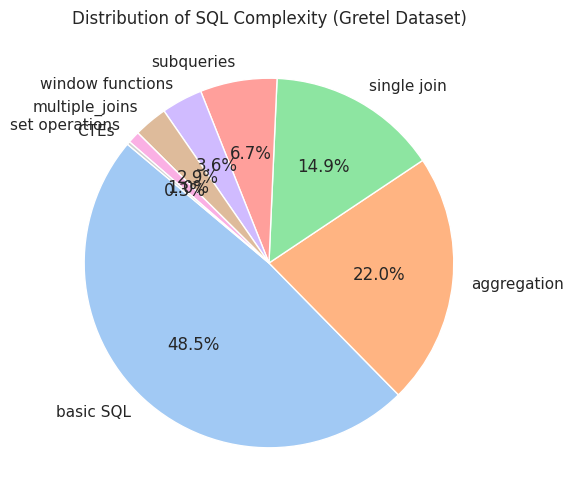

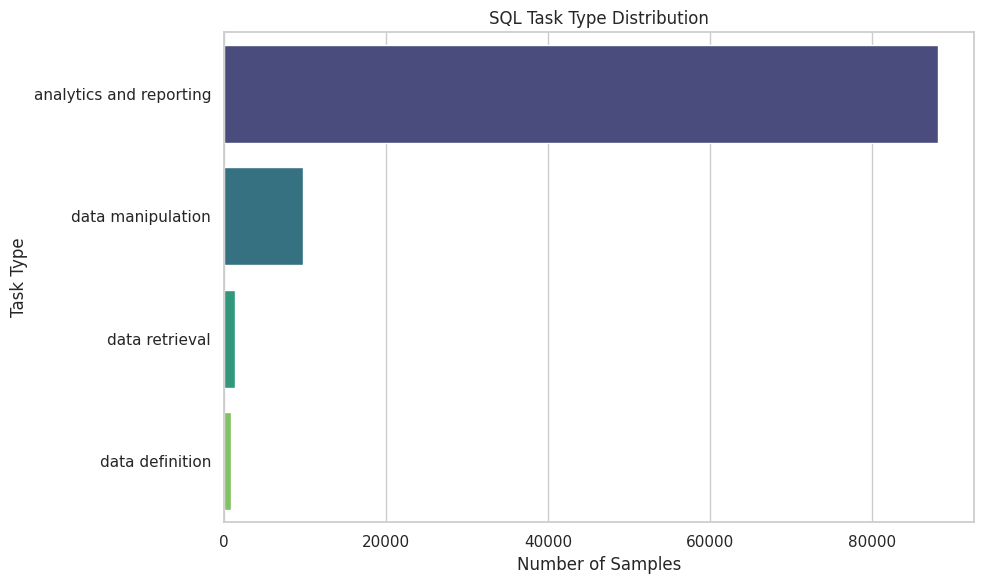

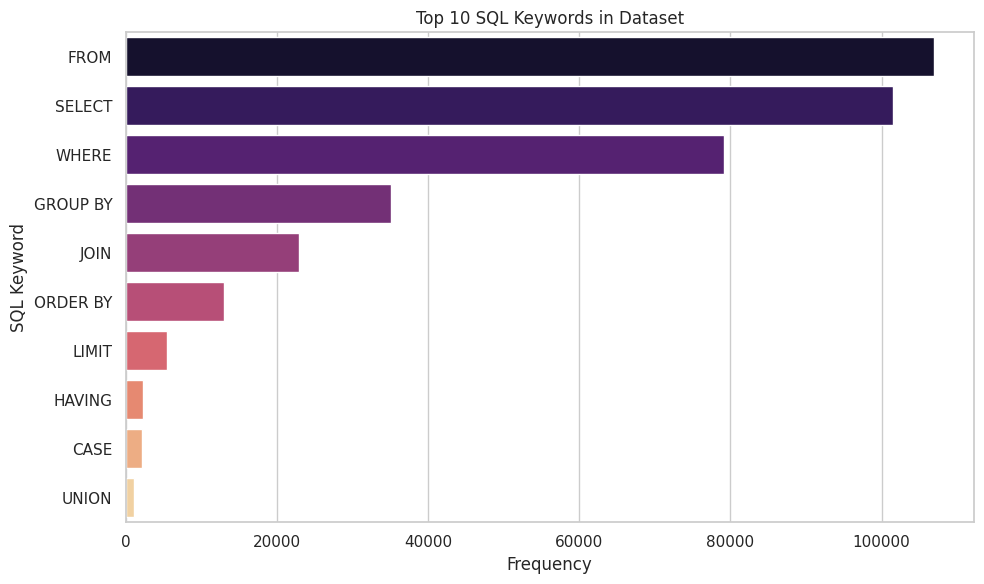

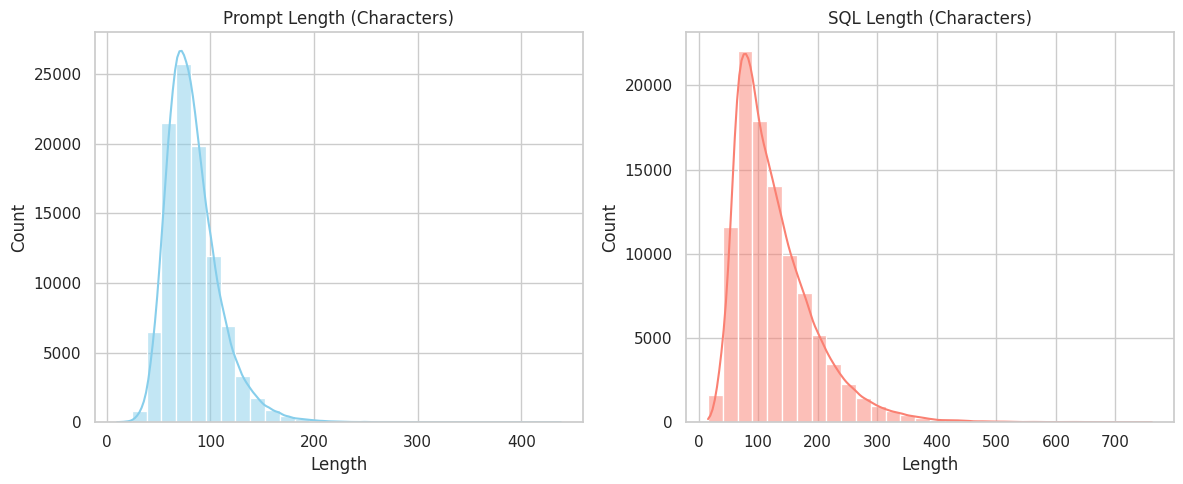

In [ ]:
# Assuming 'train_data' is your dataset object from:
# train_data = load_dataset("gretelai/synthetic_text_to_sql", split="train").select(range(10000))
# Create DataFrame from raw_subset to retain original columns for analysis
df = raw_subset.to_pandas()

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. SQL Complexity Distribution
plt.figure(figsize=(8, 6))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Distribution of SQL Complexity (Gretel Dataset)')
plt.ylabel('')
plt.savefig('sql_complexity_pie.png')

# 2. SQL Task Type Distribution
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
plt.title('SQL Task Type Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Task Type')
plt.tight_layout()
plt.savefig('task_type_bar.png')

# 3. SQL Keyword Frequency (Top 10)
def get_keywords(sql_list):
    keywords = []
    for sql in sql_list:
        # Regex to find major SQL keywords
        found = re.findall(r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|CASE|CAST|UNION|WITH|HAVING)\b', sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = get_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')
plt.title('Top 10 SQL Keywords in Dataset')
plt.xlabel('Frequency')
plt.ylabel('SQL Keyword')
plt.tight_layout()
plt.savefig('keyword_frequency.png')

# 4. Prompt vs SQL Length Distribution
df['prompt_len'] = df['sql_prompt'].apply(len)
df['sql_len'] = df['sql'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=30, color='skyblue', kde=True)
plt.title('Prompt Length (Characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=30, color='salmon', kde=True)
plt.title('SQL Length (Characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png')

# Show all plots
plt.show()

##### 5. Prompt Length vs. SQL Length

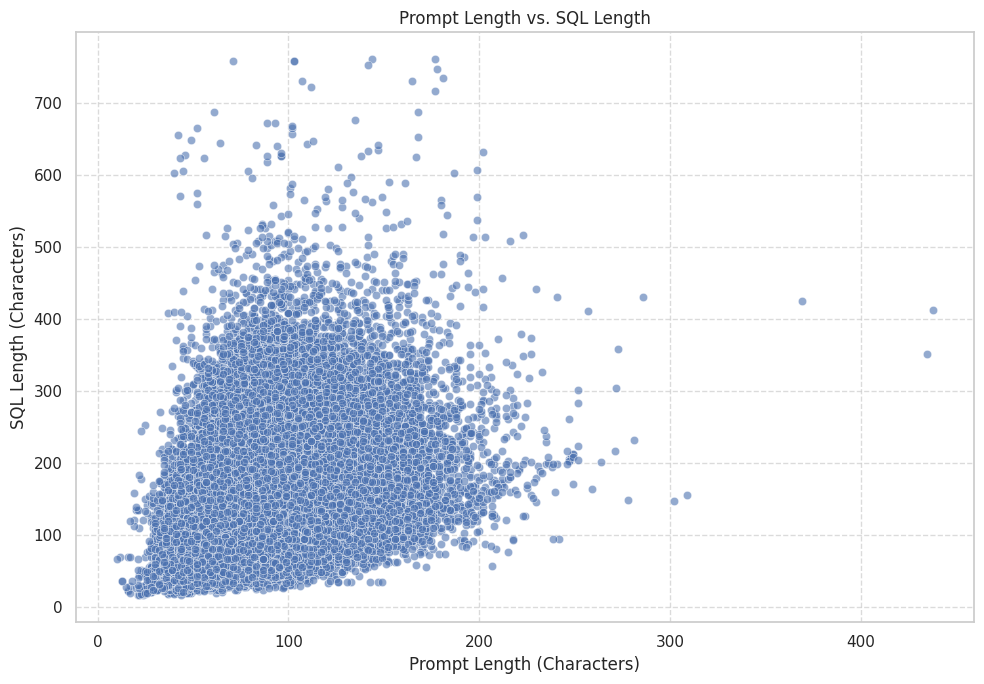

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='prompt_len', y='sql_len', alpha=0.6)
plt.title('Prompt Length vs. SQL Length')
plt.xlabel('Prompt Length (Characters)')
plt.ylabel('SQL Length (Characters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('prompt_sql_length_scatter.png')
plt.show()

##### 6. Distribution of Top 10 Domains

/tmp/ipython-input-121/1761744423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='domain', order=domain_order, palette='cividis')


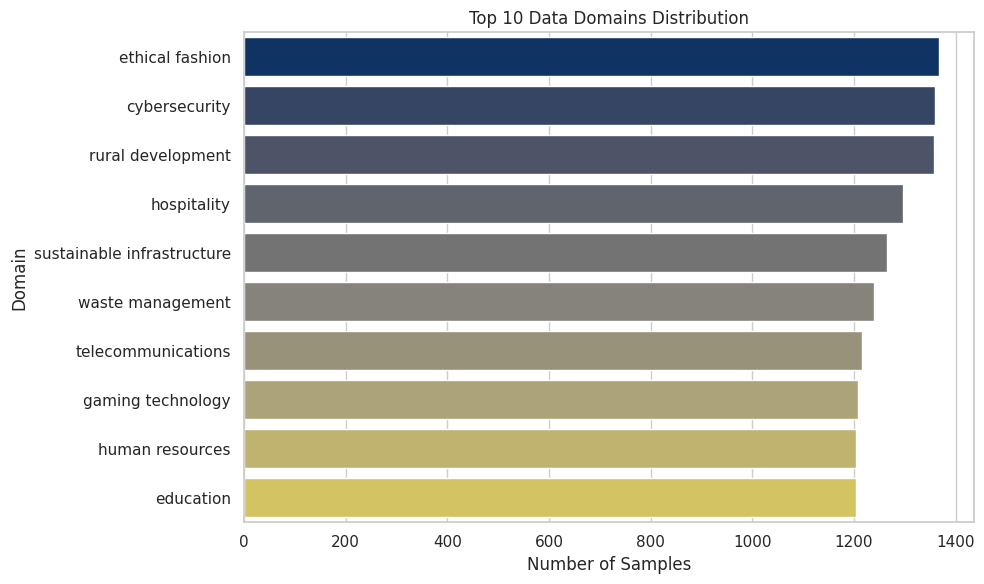

In [ ]:
plt.figure(figsize=(10, 6))
domain_order = df['domain'].value_counts().head(10).index
sns.countplot(data=df, y='domain', order=domain_order, palette='cividis')
plt.title('Top 10 Data Domains Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig('domain_distribution_bar.png')
plt.show()

##### 7. SQL Complexity by SQL Task Type

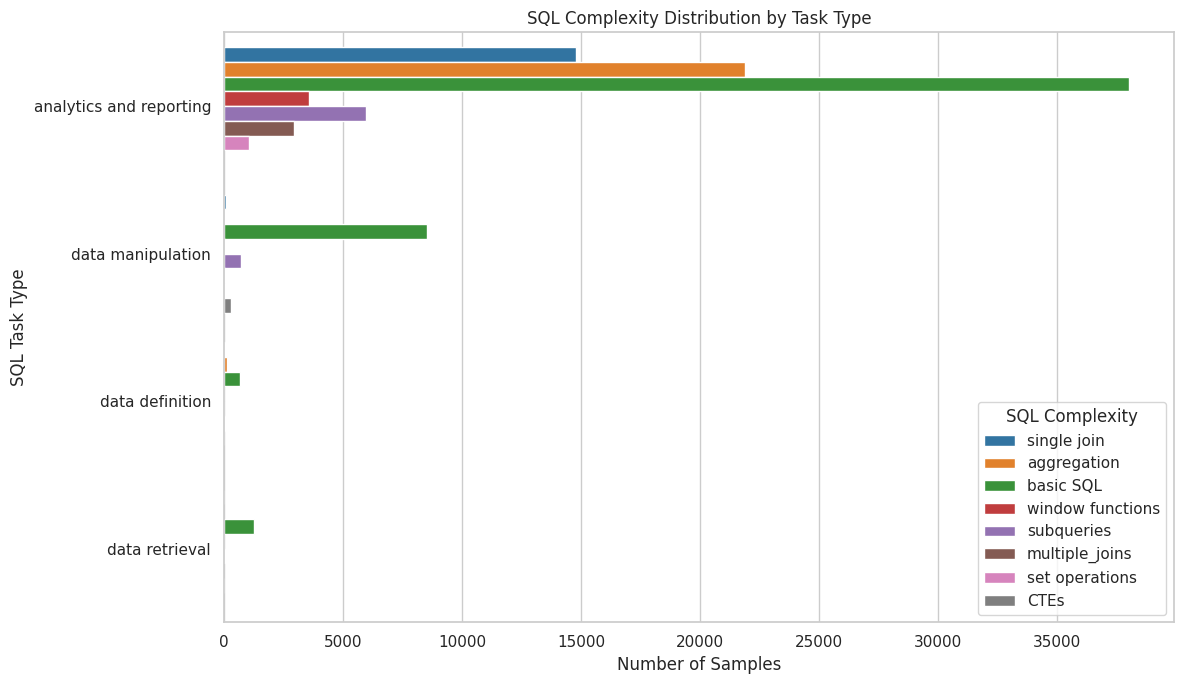

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='sql_task_type', hue='sql_complexity', palette='tab10', dodge=True)
plt.title('SQL Complexity Distribution by Task Type')
plt.xlabel('Number of Samples')
plt.ylabel('SQL Task Type')
plt.legend(title='SQL Complexity')
plt.tight_layout()
plt.savefig('complexity_by_task_type_bar.png')
plt.show()

In [ ]:
import re

def extract_joined_tables(sql_query):
    # Convert query to uppercase for case-insensitive matching
    sql_query_upper = sql_query.upper()

    # Regex to find table names after FROM or JOIN
    # It looks for 'FROM ' or 'JOIN ' followed by a word character sequence (the table name)
    # and stops before the next space, punctuation, or keyword. It also handles aliases.
    # Pattern to capture table name which might be followed by AS alias or just alias
    from_pattern = r"FROM\s+`?([A-Z0-9_]+)`?(?:\s+AS)?(?:\s+[A-Z0-9_]+)?"
    join_pattern = r"JOIN\s+`?([A-Z0-9_]+)`?(?:\s+AS)?(?:\s+[A-Z0-9_]+)?"

    from_tables = re.findall(from_pattern, sql_query_upper)
    join_tables = re.findall(join_pattern, sql_query_upper)

    # Combine and get unique table names
    all_tables = list(set(from_tables + join_tables))

    return all_tables

# Apply the function to the 'sql' column and create a new column 'joined_tables'
df['joined_tables'] = df['sql'].apply(extract_joined_tables)

# Display the first few rows with the new column
print(df[['sql', 'joined_tables']].head())

                                                 sql  \
0  SELECT salesperson_id, name, SUM(volume) as to...   
1  SELECT equipment_type, SUM(maintenance_frequen...   
2  SELECT COUNT(*) FROM marine_species WHERE loca...   
3  SELECT trader_id, stock, SUM(price * quantity)...   
4  SELECT type, cost FROM (SELECT type, cost, ROW...   

                 joined_tables  
0  [SALESPERSON, TIMBER_SALES]  
1      [EQUIPMENT_MAINTENANCE]  
2             [MARINE_SPECIES]  
3              [TRADE_HISTORY]  
4                   [UPGRADES]  


In [ ]:
from collections import Counter
import pandas as pd

# Flatten the list of lists in the 'joined_tables' column
all_joined_tables = [table for sublist in df['joined_tables'] for table in sublist]

# Count the frequency of each table
table_counts = Counter(all_joined_tables)

# Convert to DataFrame for easier handling and plotting
table_counts_df = pd.DataFrame(table_counts.items(), columns=['Table', 'Frequency'])

# Sort by frequency in descending order
table_counts_df = table_counts_df.sort_values(by='Frequency', ascending=False)

# Display the top 10 most frequently joined tables
print("\nTop 10 Most Frequently Joined Tables:")
print(table_counts_df.head(10))



Top 10 Most Frequently Joined Tables:
          Table  Frequency
141       SALES       1401
150   DONATIONS       1398
16     PRODUCTS       1388
70       DONORS       1180
203   EMPLOYEES       1101
74      PLAYERS        855
128  VOLUNTEERS        816
294       USERS        762
33    COMPANIES        703
105     ARTISTS        699


/tmp/ipython-input-121/645801061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=table_counts_df.head(10), x='Frequency', y='Table', palette='viridis')


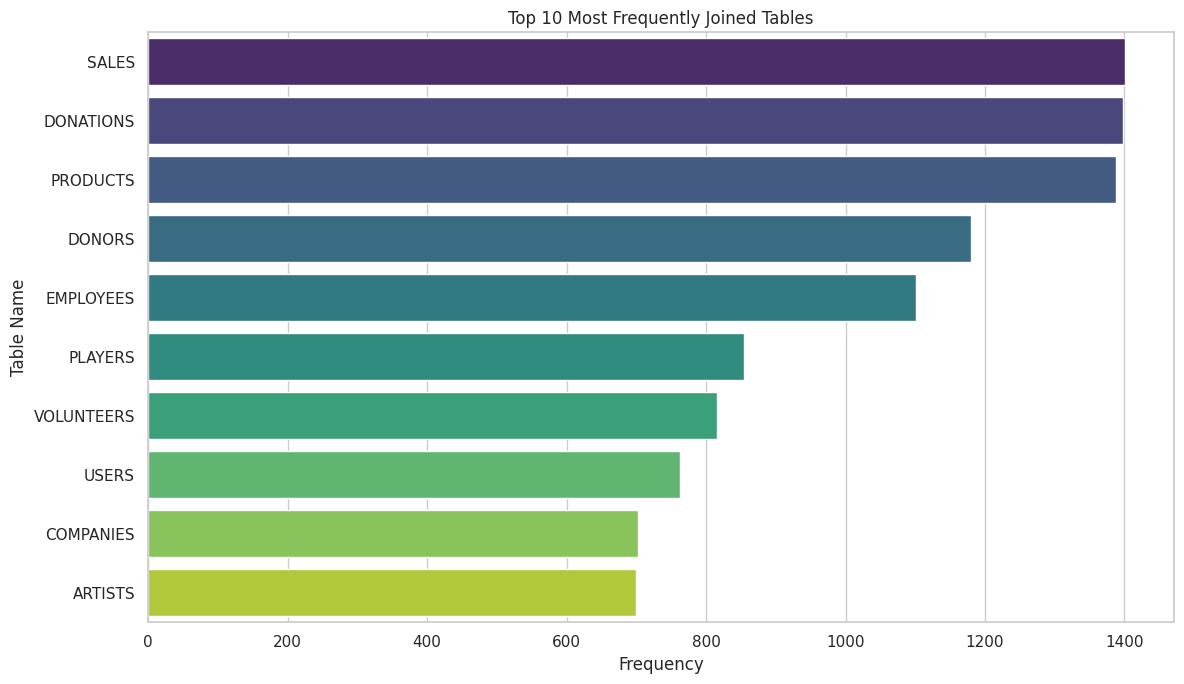

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_theme(style="whitegrid")

# Plot the top 10 most frequently joined tables
plt.figure(figsize=(12, 7))
sns.barplot(data=table_counts_df.head(10), x='Frequency', y='Table', palette='viridis')
plt.title('Top 10 Most Frequently Joined Tables')
plt.xlabel('Frequency')
plt.ylabel('Table Name')
plt.tight_layout()
plt.show()


In [ ]:
sql_complexity_distribution = df['sql_complexity'].value_counts()
print("SQL Complexity Distribution:")
print(sql_complexity_distribution)

SQL Complexity Distribution:
sql_complexity
basic SQL           48466
aggregation         22015
single join         14932
subqueries           6719
window functions     3596
multiple_joins       2949
set operations       1050
CTEs                  273
Name: count, dtype: int64


### Infrastructure Provisioning

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
%%bash
# Source gcloud environment before running installation scripts
source /root/google-cloud-sdk/path.bash.inc
source /root/google-cloud-sdk/completion.bash.inc

cd $PROJECT_DIR/setup
#chmod +x install_gcp.sh
chmod +x install_kubectl.sh
#./install_gcp.sh
./install_kubectl.sh

# Ensure gcloud SDK bin directory is in PATH for this session
export PATH=$PATH:/root/google-cloud-sdk/bin

# Verify kubectl is now accessible and gke-gcloud-auth-plugin is functional
echo "Verifying kubectl accessibility and gke-gcloud-auth-plugin:"
kubectl version --client

kubectl is already installed.
Client Version: v1.35.2
Kustomize Version: v5.7.1
Verifying kubectl accessibility and gke-gcloud-auth-plugin:
Client Version: v1.35.2
Kustomize Version: v5.7.1


bash: line 2: /root/google-cloud-sdk/path.bash.inc: No such file or directory
bash: line 3: /root/google-cloud-sdk/completion.bash.inc: No such file or directory


In [ ]:
project_id = config_loader.get('project.id')
location = config_loader.get('project.region')
CLUSTER_NAME=config_loader.get("gke.cluster.name")
CLUSTER_NODE_COUNT=config_loader.get("gke.cluster.num_nodes")
CLUSTER_MACHINE_TYPE=config_loader.get("gke.cluster.machine_type")
WORKLOAD_POOL_FULL=f"{project_id}.svc.id.goog"
NODEPOOL_NAME=config_loader.get("gke.node_pool.name")
NODEPOOL_MACHINE_TYPE=config_loader.get("gke.node_pool.machine_type")
ACCELERATOR_TYPE=config_loader.get("gke.node_pool.accelerator.type")
ACCELERATOR_COUNT=config_loader.get("gke.node_pool.accelerator.count")
NODEPOOL_NUM_NODES=config_loader.get("gke.node_pool.num_nodes")
SCOPES=config_loader.get("gke.node_pool.scopes")
REPOSITORY_NAME=config_loader.get("gke.node_pool.repository_name")
GCP_SERVICE_ACCOUNT=config_loader.get("GCP_SERVICE_ACCOUNT")


# Ensure the script is executable
!chmod +x {project_dir}/setup/create_gke_cluster.sh

# Construct the command string and execute in a single bash shell
command_str = f"""
\"{project_dir}/setup/create_gke_cluster.sh\" \
  \"{CLUSTER_NAME}\" \
  \"{project_id}\" \
  \"{location}\" \
  \"{CLUSTER_MACHINE_TYPE}\" \
  \"{CLUSTER_NODE_COUNT}\" \
  \"{WORKLOAD_POOL_FULL}\" \
  \"{NODEPOOL_NAME}\" \
  \"{NODEPOOL_MACHINE_TYPE}\" \
  \"{ACCELERATOR_TYPE}\" \
  \"{ACCELERATOR_COUNT}\" \
  \"{NODEPOOL_NUM_NODES}\" \
  \"{SCOPES}\" \
  \"{REPOSITORY_NAME}\" \
  \"{GCP_SERVICE_ACCOUNT}\" \
"""
!bash -c "{command_str}"

In [ ]:
!gcloud components install gke-gcloud-auth-plugin --quiet

In [ ]:
# 1. Install the GKE auth plugin
!sudo apt-get install google-cloud-sdk-gke-gcloud-auth-plugin

!gcloud container clusters get-credentials sdk-training-cluster --region us-central1

In [ ]:
!kubectl create serviceaccount gemma-training-job-ksa

error: failed to create serviceaccount: Unauthorized


In [ ]:
!kubectl annotate serviceaccount default \
    iam.gke.io/gcp-service-account=${os.getenv('GCP_SERVICE_ACCOUNT')}

In [ ]:
# 1. Get the Access Token
token = !gcloud auth print-access-token
token = token[0]

# 2. Get Cluster Endpoint and CA Cert
endpoint = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(endpoint)"
ca_cert = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(masterAuth.clusterCaCertificate)"

endpoint = endpoint[0]
ca_cert = ca_cert[0]

# 3. Create a manual kubeconfig file
kubeconfig = f"""
apiVersion: v1
kind: Config
clusters:
- cluster:
    certificate-authority-data: {ca_cert}
    server: https://{endpoint}
  name: gke-cluster
contexts:
- context:
    cluster: gke-cluster
    user: colab-user
  name: gke-context
current-context: gke-context
users:
- name: colab-user
  user:
    token: {token}
"""

with open("kubeconfig.yaml", "w") as f:
    f.write(kubeconfig)

# 4. Set the environment variable for kubectl
os.environ['KUBECONFIG'] = '/content/kubeconfig.yaml'

print("Kubeconfig generated! Testing connection...")
!kubectl get nodes

Kubeconfig generated! Testing connection...
NAME                                                  STATUS   ROLES    AGE   VERSION
gke-sdk-training-cluster-default-pool-1cac64d0-6prm   Ready    <none>   24m   v1.34.3-gke.1444000
gke-sdk-training-cluster-default-pool-309e2884-fhbk   Ready    <none>   24m   v1.34.3-gke.1444000
gke-sdk-training-cluster-default-pool-92f7f7b4-j54q   Ready    <none>   24m   v1.34.3-gke.1444000


In [ ]:
HF_TOKEN = config_loader.get('hf_token')
project_id = config_loader.get('project.id')
gcs_bucket = config_loader.get('data.gcs_bucket')
gcs_mount_path = f"/gcs/{gcs_bucket}"
repository_name = config_loader.get('gke.node_pool.repository_name')
ml_image_name = config_loader.get('gke.node_pool.ml_image_name')
ml_image_name='gemma_training'
ml_image_path = f"us-central1-docker.pkg.dev/{project_id}/{repository_name}/{ml_image_name}:latest"

os.environ['ML_IMAGE_PATH'] = ml_image_path
os.environ['ML_IMAGE_NAME'] = ml_image_name

In [ ]:
configmap_yaml_content = f"""apiVersion: v1
kind: ConfigMap
metadata:
  name: gemma-perf-config
data:
  GCP_PROJECT_ID_CM: "{project_id}"
  GCS_BUCKET_CM: "{gcs_bucket}"
  GCS_MOUNT_PATH: "{gcs_mount_path}"
"""

configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

print(f"Kubernetes ConfigMap YAML for gemma-perf-config created at: {configmap_yaml_path}")

Kubernetes ConfigMap YAML for gemma-perf-config created at: /content/aai-590-tinysql/job/gemma-perf-config.yaml


In [ ]:
script_template_path=f"{project_dir}/job/gemma_job_template.yaml"
script_template = ""
with open(script_template_path, "r") as f:
    script_template = f.read()

# Load the YAML template into a Python dictionary
base_job_script = yaml.safe_load(script_template)
# Correctly set the image field from the Python variable ml_image_path
base_job_script['spec']['template']['spec']['containers'][0]['image'] = ml_image_path


In [ ]:
command_str = "python3 src/model_training/gemma_vanilla_model_perf.py           --model_id 'google/gemma-3-4b-it'"

# Create a deep copy of base_job_script to ensure it remains immutable
perf_benchmark_job_dict = copy.deepcopy(base_job_script)

# Update the args in the appropriate location in the dictionary
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['args'] = [command_str]

# --- FIX: Correctly set the GCS bucket in the volumeMounts ---
# Assuming the second volumeMount (index 1) is for gcs-fuse-csi
# And the gcs_bucket variable holds the correct bucket name (from config_loader.get('data.gcs_bucket'))
# This line ensures the actual bucket name is used instead of the literal placeholder '{gcs_bucket}'
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['volumeMounts'][1]['mountPath'] = f"/gcs/{gcs_bucket}"


# Convert the dictionary back to a YAML string
perf_benchmark_job = yaml.dump(perf_benchmark_job_dict, sort_keys=False)


In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla_perf.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

In [ ]:
# Define the output directory and file path
output_dir = os.path.join(os.environ['PROJECT_DIR'], 'data')
train_output_file_path = os.path.join(output_dir, 'tinycode_train_ds.jsonl')
test_output_file_path = os.path.join(output_dir, 'tinycode_test_ds.jsonl')

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the dataset to a JSON Lines file
tinycode_train_ds.to_json(train_output_file_path)
tinycode_test_ds.to_json(test_output_file_path)

print(f"Dataset saved to: {train_output_file_path}")
print(f"Dataset saved to: {test_output_file_path}")

Creating json from Arrow format:   0%|          | 0/50 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Dataset saved to: /content/aai-590-tinysql/data/tinycode_train_ds.jsonl
Dataset saved to: /content/aai-590-tinysql/data/tinycode_test_ds.jsonl


In [ ]:
# Upload the local JSON Lines file to the GCS bucket
# The output_file_path and gcs_bucket variables are available from previous cells.
!gsutil cp {train_output_file_path} gs://{gcs_bucket}/data/tinycode_train_ds.jsonl
!gsutil cp {test_output_file_path} gs://{gcs_bucket}/data/tinycode_test_ds.jsonl

print(f"Dataset uploaded to gs://{gcs_bucket}/data/tinycode_train_ds.jsonl")

Copying file:///content/aai-590-tinysql/data/tinycode_train_ds.jsonl [Content-Type=application/octet-stream]...
- [1 files][ 58.9 MiB/ 58.9 MiB]                                                
Operation completed over 1 objects/58.9 MiB.                                     
Copying file:///content/aai-590-tinysql/data/tinycode_test_ds.jsonl [Content-Type=application/octet-stream]...
/ [1 files][  5.6 MiB/  5.6 MiB]                                                
Operation completed over 1 objects/5.6 MiB.                                      
Dataset uploaded to gs://cfpb-raw-lake-sdk/data/tinycode_train_ds.jsonl


In [ ]:
!kubectl get pods

No resources found in default namespace.


#### Image Creation

In [ ]:
%%bash
# Build and push the Docker image to Google Artifact Registry

# Ensure the script stops if any command fails
set -e

# Navigate to the project directory
cd $PROJECT_DIR

# Build the Docker image and tag it
echo "Building Docker image: " $ML_IMAGE_PATH
gcloud builds submit . --tag $ML_IMAGE_PATH

echo "Docker image build and push complete."

### Backup

In [ ]:
%%bash
zip -r /content/aai-590-tinysql.zip /content/aai-590-tinysql

echo "Zip file created at /content/aai-590-tinysql.zip"

  adding: content/aai-590-tinysql/ (stored 0%)
  adding: content/aai-590-tinysql/Dockerfile (deflated 36%)
  adding: content/aai-590-tinysql/setup/ (stored 0%)
  adding: content/aai-590-tinysql/setup/install_gcp.sh (deflated 56%)
  adding: content/aai-590-tinysql/setup/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/setup/create_gke_cluster.sh (deflated 66%)
  adding: content/aai-590-tinysql/setup/install_kubectl.sh (deflated 50%)
  adding: content/aai-590-tinysql/env.txt (deflated 22%)
  adding: content/aai-590-tinysql/config/ (stored 0%)
  adding: content/aai-590-tinysql/config/config.yaml (deflated 54%)
  adding: content/aai-590-tinysql/config/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/src/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/perf_testing.py (deflated 62%)
  adding: content/aai-590-tinysql/src/model_training/.ipynb_checkpoints/ (stored 0%)
  adding:

In [ ]:
from google.colab import files
files.download('/content/aai-590-tinysql.zip')

In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla_perf.yaml"
with open(gemma_vanilla_perf_yaml_path, "w") as f:
    f.write(perf_benchmark_job)

print(f"Kubernetes job configuration saved to: {gemma_vanilla_perf_yaml_path}")


Kubernetes job configuration saved to: /content/aai-590-tinysql/job/gemma-vanilla_perf.yaml


In [ ]:
!kubectl apply -f {gemma_vanilla_perf_yaml_path}

job.batch/gemma-vanilla-perf-job created


In [ ]:
job_name = "gemma-vanilla-perf-job"
!kubectl delete job {job_name} --ignore-not-found=true


job.batch "gemma-vanilla-perf-job" deleted from default namespace


In [ ]:
!kubectl apply -f {gemma_vanilla_perf_yaml_path}

job.batch/gemma-vanilla-perf-job created


In [ ]:
job_name = "gemma-vanilla-perf-job"
!kubectl get pods -l job-name={job_name}

NAME                           READY   STATUS     RESTARTS   AGE
gemma-vanilla-perf-job-njlfn   0/2     Init:0/1   0          12s


In [ ]:
import time

job_name = "gemma-vanilla-perf-job"

# Get the pod name
pods_output = !kubectl get pods -l job-name={job_name} -o=jsonpath='{.items[0].metadata.name}'
pod_name = pods_output[0]

if not pod_name:
    print(f"No pod found for job {job_name}")
else:
    print(f"Found pod: {pod_name}")

    # Wait for the pod to be in Running state
    print(f"Waiting for pod {pod_name} to be in 'Running' status...")
    while True:
        status_output = !kubectl get pod {pod_name} -o=jsonpath='{.status.phase}'
        pod_status = status_output[0]
        print(f"Current status: {pod_status}")
        if pod_status == 'Running':
            print(f"Pod {pod_name} is now Running!")
            break
        elif pod_status in ['Pending', 'ContainerCreating', 'Init:0/1']:
            print(f"Pod {pod_name} is still {pod_status}. Waiting...")
            time.sleep(10) # Wait 10 seconds before checking again
        else:
            print(f"Pod {pod_name} entered an unexpected state: {pod_status}. Exiting.")
            break

    # Open an interactive shell session
    if pod_status == 'Running':
        print(f"Opening interactive shell session to {pod_name}...")
        !kubectl exec -it {pod_name} -- bash
    else:
        print("Cannot open shell: Pod is not in 'Running' state.")

Found pod: Error from server (BadRequest): Unable to find "/v1, Resource=pods" that match label selector "job-name={job_name}", field selector "": unable to parse requirement: values[0][job-name]: Invalid value: "{job_name}": a valid label must be an empty string or consist of alphanumeric characters, '-', '_' or '.', and must start and end with an alphanumeric character (e.g. 'MyValue',  or 'my_value',  or '12345', regex used for validation is '(([A-Za-z0-9][-A-Za-z0-9_.]*)?[A-Za-z0-9])?')
Waiting for pod Error from server (BadRequest): Unable to find "/v1, Resource=pods" that match label selector "job-name={job_name}", field selector "": unable to parse requirement: values[0][job-name]: Invalid value: "{job_name}": a valid label must be an empty string or consist of alphanumeric characters, '-', '_' or '.', and must start and end with an alphanumeric character (e.g. 'MyValue',  or 'my_value',  or '12345', regex used for validation is '(([A-Za-z0-9][-A-Za-z0-9_.]*)?[A-Za-z0-9])?') to 

In [ ]:
import time
import shlex # For proper shell quoting

job_name = "gemma-vanilla-perf-job"

# Construct the command string safely to get the pod name
# The jsonpath expression also needs to be correctly embedded and quoted for the shell
get_pod_name_cmd = f"kubectl get pods -l job-name={shlex.quote(job_name)} -o=jsonpath='{{.items[0].metadata.name}}'"
pods_output = !bash -c "{get_pod_name_cmd}"

# Assuming the output is a list, and the first element is the pod name
pod_name = pods_output[0].strip() if pods_output and pods_output[0].strip() else ""

if not pod_name:
    print(f"No pod found for job {job_name}. Command output: {pods_output}")
else:
    print(f"Found pod: {pod_name}")

    # Wait for the pod to be in Running state
    print(f"Waiting for pod {pod_name} to be in 'Running' status...")
    while True:
        # Construct the command string safely to get the pod status
        get_status_cmd = f"kubectl get pod {shlex.quote(pod_name)} -o=jsonpath='{{.status.phase}}'"
        status_output = !bash -c "{get_status_cmd}"

        if status_output and status_output[0].strip():
            pod_status = status_output[0].strip()
        else:
            pod_status = "Unknown" # Handle cases where output is empty or command fails

        print(f"Current status: {pod_status}")
        if pod_status == 'Running':
            print(f"Pod {pod_name} is now Running!")
            break
        elif pod_status in ['Pending', 'ContainerCreating', 'Init:0/1']:
            print(f"Pod {pod_name} is still {pod_status}. Waiting...")
            time.sleep(10) # Wait 10 seconds before checking again
        else:
            print(f"Pod {pod_name} entered an unexpected state: {pod_status}. Exiting.")
            break

    # Open an interactive shell session
    if pod_status == 'Running':
        print(f"Opening interactive shell session to {pod_name}...")
        # Construct the command string safely for kubectl exec
        exec_cmd = f"kubectl exec -it {shlex.quote(pod_name)} -- bash"
        !bash -c "{exec_cmd}"
    else:
        print("Cannot open shell: Pod is not in 'Running' state.")

Found pod: gemma-vanilla-perf-job-njlfn
Waiting for pod gemma-vanilla-perf-job-njlfn to be in 'Running' status...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Po

In [ ]:
%%bash
export GCS_BUCKET=$(kubectl get configmap gemma-perf-config -o jsonpath='{.data.GCS_BUCKET_CM}')
envsubst < ${PROJECT_DIR}/job/gemma-vanilla_perf.yaml | kubectl apply -f -

In [ ]:
%%bash

    gcloud container node-pools create gpu-pool2 \
      --cluster=sdk-training-cluster \
      --project=gpu-launchpad-playground \
      --region=us-central1 \
      --disk-size=500 \
      --machine-type=g2-standard-16 \
      --accelerator="type=nvidia-l4,count=1" \
      --num-nodes=1 \
      --enable-autoscaling --min-nodes="0" --max-nodes=1